# Thesis Figure 9 Ã¢â‚¬â€ Saliency Map Construction (Step-by-step)

For one image and one region index, shows:
1. **Region at each desired length** Ã¢â‚¬â€ region mask overlaid in red, one panel per length.
2. **Summed mask** Ã¢â‚¬â€ accumulation heatmap: the more lengths covered a pixel, the more red.
3. **Blurred sum** Ã¢â‚¬â€ Gaussian blur of the sum.
4. **Final saliency** Ã¢â‚¬â€ normalised to [0,1], jet colormap overlay.

Edit only the **Configuration** cell.

In [10]:
import json
import os
import re
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import torch
from mlflow.tracking import MlflowClient
from scipy.ndimage import gaussian_filter


REPO_ROOT = Path("../..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from ciao.data.preprocessing import load_and_preprocess_image
from ciao.visualization.visualization import _to_hwc


# Ã¢â€â‚¬Ã¢â€â‚¬ MLflow Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
TRACKING_URI = "https://mlflow.rationai.cloud.e-infra.cz/"
EXPERIMENT_NAME = "algorithm-comparison-imagenet-s"
os.environ["MLFLOW_TRACKING_USERNAME"] = "YOUR_MLFLOW_USERNAME"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "YOUR_MLFLOW_PASSWORD"

# Ã¢â€â‚¬Ã¢â€â‚¬ Image Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
IMAGE_NAME = "imagenets_0054.jpg"
LOCAL_IMAGES_PATH = Path("REPO_ROOT/images/images")

# Ã¢â€â‚¬Ã¢â€â‚¬ CIAO settings Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
ALL_DESIRED_LENGTHS = [15, 30, 60, 90]  # lengths used in the UCB experiment
REGION_IDX = 0  # which region to visualise (0 = best)
SIGMA_FRACTION = 0.03  # Gaussian sigma = fraction of shorter side

# Ã¢â€â‚¬Ã¢â€â‚¬ Visual settings Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
RED_ALPHA = 0.55  # opacity of the red region overlay
SAL_ALPHA = 0.55  # opacity of the final saliency jet overlay

# Ã¢â€â‚¬Ã¢â€â‚¬ Output Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
OUTPUT_DIR = Path("output/09_saliency_construction")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [11]:
mlflow.set_tracking_uri(TRACKING_URI)
client = MlflowClient(tracking_uri=TRACKING_URI)
_name_re = re.compile(r"^(?P<label>.+)-(?P<seed>\d+)-length-(?P<length>\d+)$")


def _npy(run_id: str, name: str) -> np.ndarray | None:
    try:
        with tempfile.TemporaryDirectory() as d:
            p = client.download_artifacts(run_id, name, dst_path=d)
            return np.load(p)
    except Exception:
        return None


def _json_art(run_id: str, path: str) -> dict | None:
    try:
        with tempfile.TemporaryDirectory() as d:
            p = client.download_artifacts(run_id, path, dst_path=d)
            with open(p) as f:
                return json.load(f)
    except Exception:
        return None


def _binary_mask(segs: np.ndarray, ids: list[int]) -> np.ndarray:
    m = np.zeros(segs.shape, dtype=bool)
    for s in ids:
        m |= segs == s
    return m


def _red_overlay(
    img: np.ndarray, mask: np.ndarray, alpha: float = RED_ALPHA
) -> np.ndarray:
    out = img.copy()
    out[mask] = out[mask] * (1 - alpha) + np.array([1.0, 0.0, 0.0]) * alpha
    return out


def _save_single(img_np: np.ndarray, path: Path, dpi: int = 150) -> None:
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(img_np, interpolation="nearest")
    ax.axis("off")
    fig.tight_layout(pad=0)
    fig.savefig(path, dpi=dpi, bbox_inches="tight", pad_inches=0)
    fig.savefig(path.with_suffix(".pdf"), dpi=dpi, bbox_inches="tight", pad_inches=0)
    plt.close(fig)

In [12]:
# Load experiment runs and build UCB lookup
exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if exp is None:
    raise RuntimeError(f"Experiment '{EXPERIMENT_NAME}' not found")
all_runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id], output_format="pandas"
)

parents = all_runs[all_runs["tags.mlflow.parentRunId"].isna()].copy()
children = all_runs[all_runs["tags.mlflow.parentRunId"].notna()].copy()


def _parse(name):
    m = _name_re.match(str(name) if isinstance(name, str) else "")
    if not m:
        return None, None, None
    return m.group("label"), int(m.group("seed")), int(m.group("length"))


_p = parents["tags.mlflow.runName"].apply(_parse)
parents = parents.assign(
    label=_p.apply(lambda x: x[0]),
    desired_length=_p.apply(lambda x: x[2]),
)

merged = children.merge(
    parents[["run_id", "label", "desired_length"]].dropna(subset=["label"]),
    left_on="tags.mlflow.parentRunId",
    right_on="run_id",
    suffixes=("", "_parent"),
    how="inner",
)
merged["image_name"] = merged["tags.mlflow.runName"]
merged["desired_length"] = merged["desired_length"].astype(int)
ucb = merged[merged["label"] == "ucb"].copy()

# {image_name: {length: run_id}}
ucb_lookup: dict[str, dict[int, str]] = {}
for _, r in ucb.iterrows():
    ucb_lookup.setdefault(r["image_name"], {})[r["desired_length"]] = r["run_id"]

available = sorted(ucb_lookup.get(IMAGE_NAME, {}).keys())
print(f"Available UCB lengths for '{IMAGE_NAME}': {available}")

# Original image
device = torch.device("cpu")
img_tensor = load_and_preprocess_image(LOCAL_IMAGES_PATH / IMAGE_NAME, device=device)
img_np = _to_hwc(img_tensor.unsqueeze(0))
print(f"Image shape: {img_np.shape}")

Available UCB lengths for 'imagenets_0054.jpg': [15, 30, 60, 90]
Image shape: (224, 224, 3)


In [13]:
# For each length: download segments.npy + region_{REGION_IDX}/segments.json
region_masks: dict[int, np.ndarray] = {}  # length Ã¢â€ â€™ boolean mask
segs_npy_ref: np.ndarray | None = None  # segments array (same across lengths)

for length in ALL_DESIRED_LENGTHS:
    rid = ucb_lookup.get(IMAGE_NAME, {}).get(length)
    if rid is None:
        print(f"length={length}: no run")
        continue
    segs = _npy(rid, "segments.npy")
    if segs is None:
        print(f"length={length}: segments.npy missing")
        continue
    if segs_npy_ref is None:
        segs_npy_ref = segs

    d = _json_art(rid, f"region_{REGION_IDX}/segments.json")
    if d is None:
        print(f"length={length}: region_{REGION_IDX} not found")
        continue

    ids = d["segments"]
    region_masks[length] = _binary_mask(segs, ids)
    print(
        f"length={length}: region_{REGION_IDX} has {len(ids)} segments, "
        f"{int(region_masks[length].sum())} pixels"
    )

if not region_masks:
    raise RuntimeError("No region masks found Ã¢â‚¬â€ check IMAGE_NAME and REGION_IDX")

length=15: region_0 has 15 segments, 615 pixels


length=30: region_0 has 30 segments, 1238 pixels


length=60: region_0 has 60 segments, 2493 pixels


length=90: region_0 has 90 segments, 3751 pixels


In [14]:
# Accumulate region_0 masks and compute construction steps
ordered_lengths = sorted(region_masks.keys())

# Summed count map: each pixel = number of lengths that included it in region_0
summed = sum(region_masks[l].astype(np.float32) for l in ordered_lengths)

# Blurred sum
sigma = SIGMA_FRACTION * min(summed.shape)
blurred = gaussian_filter(summed, sigma=sigma)

# Normalised saliency
max_val = float(blurred.max())
saliency = blurred / max_val if max_val > 0 else blurred

print(f"Sigma (px): {sigma:.1f}")
print(f"Sum range: [{summed.min():.0f}, {summed.max():.0f}]")
print(f"Saliency range: [{saliency.min():.3f}, {saliency.max():.3f}]")

Sigma (px): 6.7
Sum range: [0, 4]
Saliency range: [0.000, 1.000]


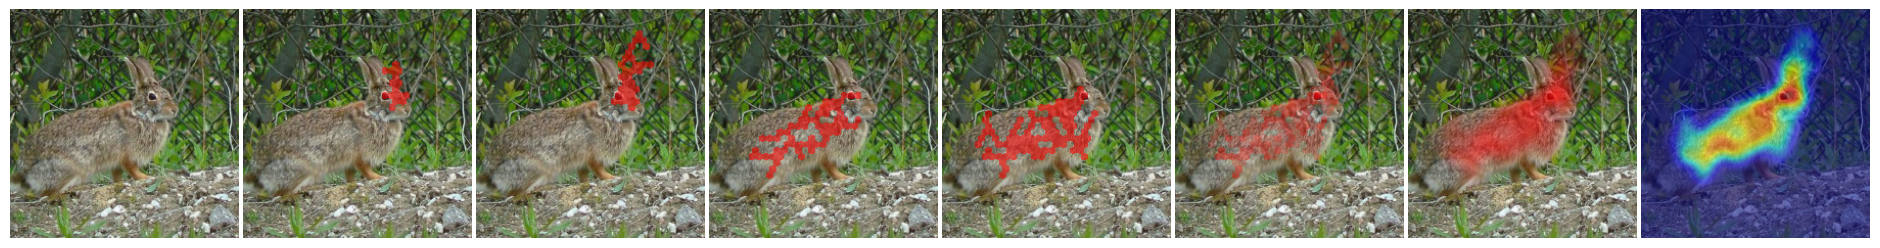

Saved Ã¢â€ â€™ output\09_saliency_construction/saliency_construction_strip.png


In [15]:
# Ã¢â€â‚¬Ã¢â€â‚¬ Single-row strip figure Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
# Panels: [original] + [region at L=15] + [L=30] + ... + [sum] + [blurred] + [saliency]

panels = []
panel_labels = []

# 1. Original
panels.append(img_np)
panel_labels.append("original")

# 2. Region overlays per length
for length in ordered_lengths:
    panels.append(_red_overlay(img_np, region_masks[length]))
    panel_labels.append(f"L={length}")

# 3. Sum as intensity overlay (scale to [0,1] for display)
sum_norm = summed / max(float(summed.max()), 1.0)
sum_overlay = np.zeros((*img_np.shape[:2], 3), dtype=np.float32)
sum_overlay[..., 0] = sum_norm  # red channel encodes count
panels.append(
    np.clip(img_np * (1 - sum_norm[..., None] * 0.7) + sum_overlay * 0.7, 0, 1)
)
panel_labels.append("sum")

# 4. Blurred sum overlay
blur_norm = blurred / max(float(blurred.max()), 1e-9)
blur_overlay = np.zeros((*img_np.shape[:2], 3), dtype=np.float32)
blur_overlay[..., 0] = blur_norm
panels.append(
    np.clip(img_np * (1 - blur_norm[..., None] * 0.7) + blur_overlay * 0.7, 0, 1)
)
panel_labels.append("blurred")

# 5. Final saliency
panels.append(None)  # placeholder Ã¢â‚¬â€ uses jet overlay
panel_labels.append("saliency")

N = len(panels)
fig, axes = plt.subplots(1, N, figsize=(3 * N, 3))
if N == 1:
    axes = [axes]

for ax, panel, label in zip(axes, panels, panel_labels, strict=False):
    if panel is None:  # saliency jet overlay
        ax.imshow(img_np)
        ax.imshow(saliency, cmap="jet", alpha=SAL_ALPHA, vmin=0.0, vmax=1.0)
    else:
        ax.imshow(panel)
    ax.axis("off")

fig.subplots_adjust(wspace=0.02)
for sfx in [".png", ".pdf"]:
    fig.savefig(
        OUTPUT_DIR / f"saliency_construction_strip{sfx}",
        dpi=150,
        bbox_inches="tight",
        pad_inches=0.02,
    )
plt.show()
print(f"Saved Ã¢â€ â€™ {OUTPUT_DIR}/saliency_construction_strip.png")

In [16]:
img_dir = OUTPUT_DIR / Path(IMAGE_NAME).stem
img_dir.mkdir(parents=True, exist_ok=True)

# Original
_save_single(img_np, img_dir / "original.png")

# Region overlay per length
for length in ordered_lengths:
    ov = _red_overlay(img_np, region_masks[length])
    _save_single(ov, img_dir / f"region_{REGION_IDX}_l{length}.png")

# Summed mask overlay
sum_panel = np.clip(img_np * (1 - sum_norm[..., None] * 0.7) + sum_overlay * 0.7, 0, 1)
_save_single(sum_panel, img_dir / "sum_overlay.png")

# Blurred sum overlay
blur_panel = np.clip(
    img_np * (1 - blur_norm[..., None] * 0.7) + blur_overlay * 0.7, 0, 1
)
_save_single(blur_panel, img_dir / "blurred_overlay.png")

# Final saliency jet
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(img_np)
ax.imshow(saliency, cmap="jet", alpha=SAL_ALPHA, vmin=0.0, vmax=1.0)
ax.axis("off")
fig.tight_layout(pad=0)
for sfx in [".png", ".pdf"]:
    fig.savefig(img_dir / f"saliency{sfx}", dpi=150, bbox_inches="tight", pad_inches=0)
plt.close(fig)

print(f"Saved individual panels to {img_dir}/")

Saved individual panels to output\09_saliency_construction\imagenets_0054/
